In [2]:
import numpy as np
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])

rowMean = A.mean(axis=1)
print("Row Means are: ",rowMean)

B= (A >rowMean[:,None]).astype(int)

B[:,1::2] = 0

print("binary Matrix is:\n",B)

count = (A>rowMean[:,None]).sum(axis=1)
print("Maximum count:",count.max())
print("Rows:",np.where(count == count.max())[0]+1)

Row Means are:  [11.25  9.   14.5  10.5 ]
binary Matrix is:
 [[1 0 0 0]
 [0 0 0 0]
 [1 0 1 0]
 [0 0 0 0]]
Maximum count: 2
Rows: [1 2 3 4]


In [4]:
import numpy as np

X = np.array([[10, 100, 5],
              [12, 110, 6],
              [11, 105, 7],
              [13, 500, 6],
              [14, 108, 8],
              [15, 115, 9]])

mean = X.mean(axis = 0)
std = X.std(axis=0)
print("Mean:",mean)
print("Std:",std)

values = np.abs(X-mean) > 2*std
print("The values are:\n",values)

median = np.median(X,axis=0)
X_clean = np.where(values,median,X)

print("Final Matrix:\n", X_clean)


Mean: [ 12.5        173.           6.83333333]
Std: [  1.70782513 146.31017281   1.34370962]
The values are:
 [[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]
Final Matrix:
 [[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


In [5]:
import pandas as pd

df = pd.DataFrame({
    'Student':['A','B','C','D','E','F','G','H'],
    'Department':['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender':['F','M','F','F','M','F','M','F'],
    'Marks':[85,72,91,65,78,88,95,70],
    'Attendance':[92,81,96,72,85,90,98,75]
})


print(df.groupby('Department')['Marks'].mean())
print(df.groupby(['Department','Gender'])['Marks'].mean())
print(df.loc[df.groupby('Department')['Marks'].idxmax()])
avg = df.groupby('Department')['Marks'].transform('mean')
print(df[df['Marks'] > avg])
print(df.groupby('Department')['Attendance'].mean().idxmax())

Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64
Department  Gender
CSE         F         85.000000
            M         81.666667
ECE         F         78.500000
Name: Marks, dtype: float64
  Student Department Gender  Marks  Attendance
6       G        CSE      M     95          98
2       C        ECE      F     91          96
  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      M     95          98
CSE


In [6]:
import pandas as pd

df = pd.DataFrame({
    'Date':['2026-01-01','2026-01-04','2026-01-05',
            '2026-01-08','2026-01-09'],
    'Sales':[100,120,150,130,180]
})
df['Date'] = pd.to_datetime(df['Date'])
all_dates = pd.date_range(df['Date'].min(), df['Date'].max())
print(all_dates.difference(df['Date']))
df = df.set_index('Date').reindex(all_dates)
df.index.name ='Date'
df['Rolling'] = df['Sales'].rolling(3).mean()

print(df)
print(df['Rolling'].idxmax())

DatetimeIndex(['2026-01-02', '2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)
            Sales  Rolling
Date                      
2026-01-01  100.0      NaN
2026-01-02    NaN      NaN
2026-01-03    NaN      NaN
2026-01-04  120.0      NaN
2026-01-05  150.0      NaN
2026-01-06    NaN      NaN
2026-01-07    NaN      NaN
2026-01-08  130.0      NaN
2026-01-09  180.0      NaN
NaT


/tmp/ipykernel_3192/2729015335.py:16: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  print(df['Rolling'].idxmax())


In [7]:
import numpy as np

P = np.array([[1, 2],
              [4, 6],
              [7, 3],
              [2, 8],
              [9, 5]])
D = P[:,None,:] - P[None,:,:]
dist = np.sqrt(np.sum(D**2, axis=2))
print(dist)
i,j =np.unravel_index(np.argmax(dist), dist.shape)
print("Maximum distance:", dist[i, j])
print("Points:", i + 1, "and", j + 1)

[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]
Maximum distance: 8.54400374531753
Points: 1 and 5


Dataset: asia_gdp.csv

rows and columns: (40, 11)

Column names:
['Country Name', 'Indicator Name', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021']

Missing values:
Country Name      0
Indicator Name    0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
dtype: int64

Duplicate rows: 0

Basic statistics:
            2013       2014       2015       2016       2017       2018  \
count  40.000000  40.000000  40.000000  40.000000  40.000000  40.000000   
mean    3.902353   4.067410   3.353442   3.547862   4.050470   4.233947   
std     3.458435   2.875449   4.591701   2.693338   2.157308   2.391052   
min    -3.561519  -3.402898 -20.348742  -4.748693   0.238774   0.410595   
25%     1.996488   2.389138   2.269965   1.732540   2.397700   2.566176   
50%     4.402063   4.418831   3.454316   3.044855   3.997563   3.833286   
75%     5.85765

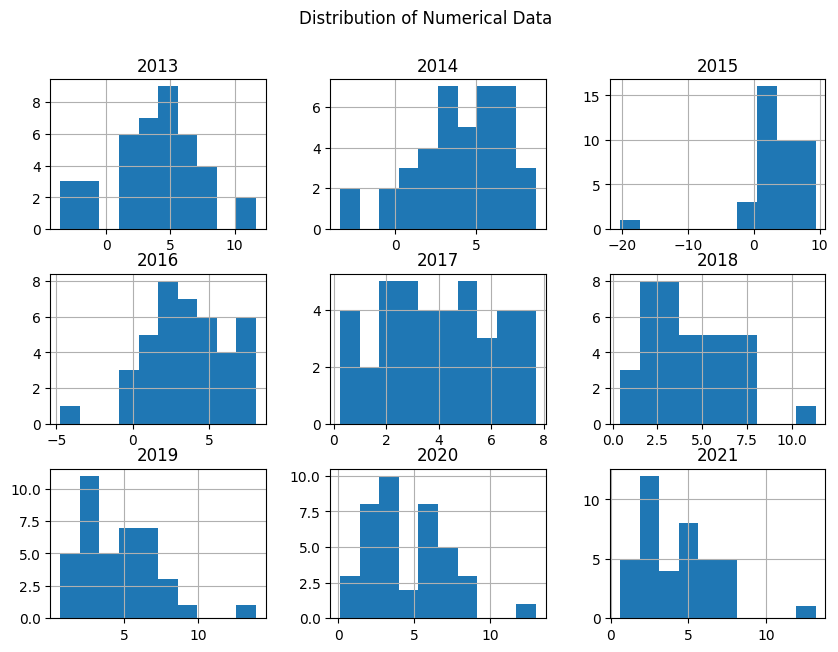

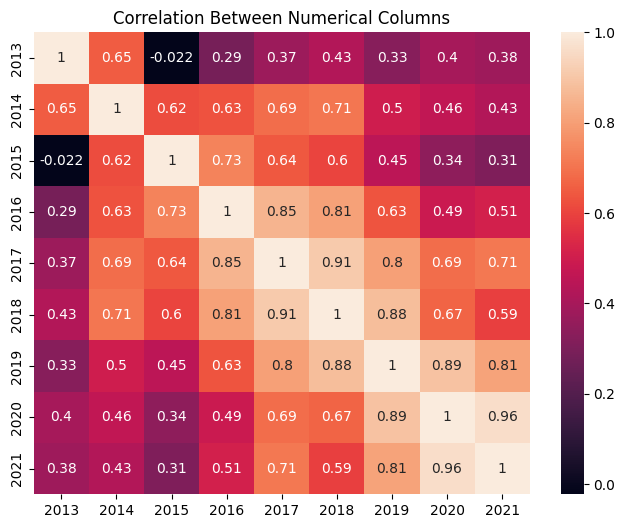

Dataset: automobile.csv

rows and columns: (202, 26)

Column names:
['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

Missing values:
symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  0
stroke                0
compression-ratio     0
horsepower            0
peak-rpm              0
city

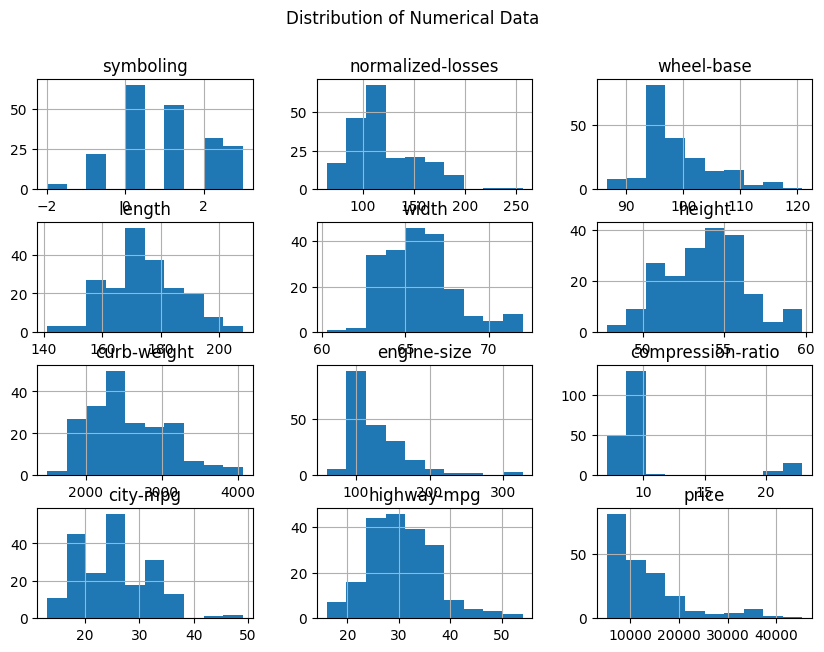

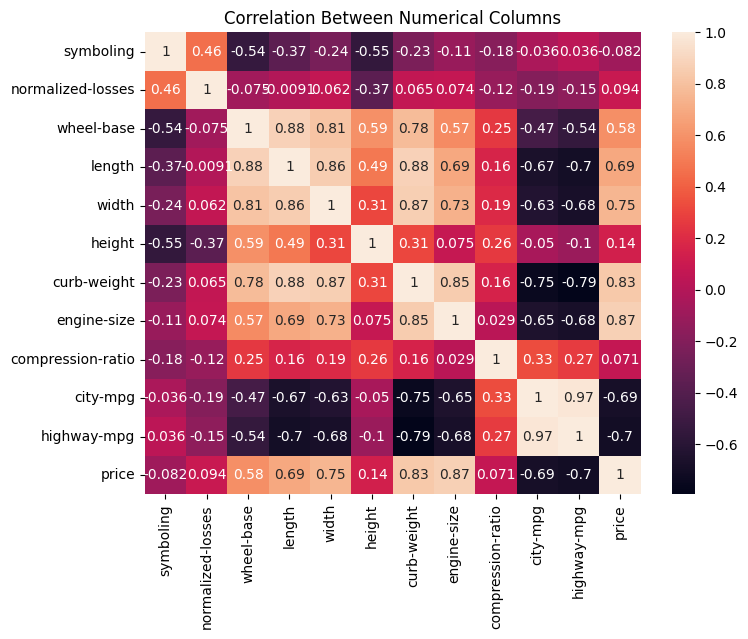

Dataset: blood.csv

rows and columns: (748, 5)

Column names:
['Recency', 'Frequency', 'Monetary', 'Time', 'Class']

Missing values:
Recency      0
Frequency    0
Monetary     0
Time         0
Class        0
dtype: int64

Duplicate rows: 215

Basic statistics:
          Recency   Frequency      Monetary        Time       Class
count  748.000000  748.000000    748.000000  748.000000  748.000000
mean     9.506684    5.514706   1378.676471   34.282086    0.237968
std      8.095396    5.839307   1459.826781   24.376714    0.426124
min      0.000000    1.000000    250.000000    2.000000    0.000000
25%      2.750000    2.000000    500.000000   16.000000    0.000000
50%      7.000000    4.000000   1000.000000   28.000000    0.000000
75%     14.000000    7.000000   1750.000000   50.000000    0.000000
max     74.000000   50.000000  12500.000000   98.000000    1.000000

Cleaning completed!


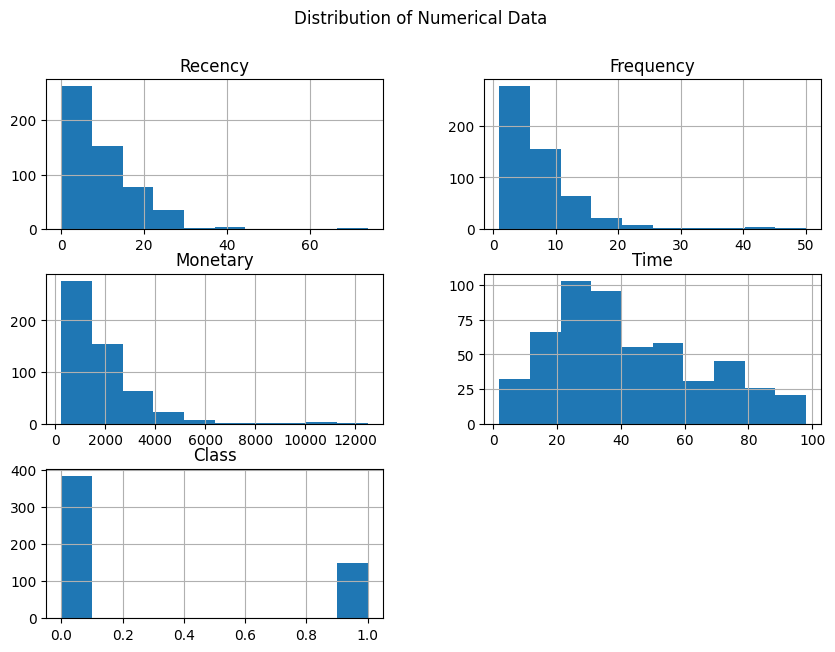

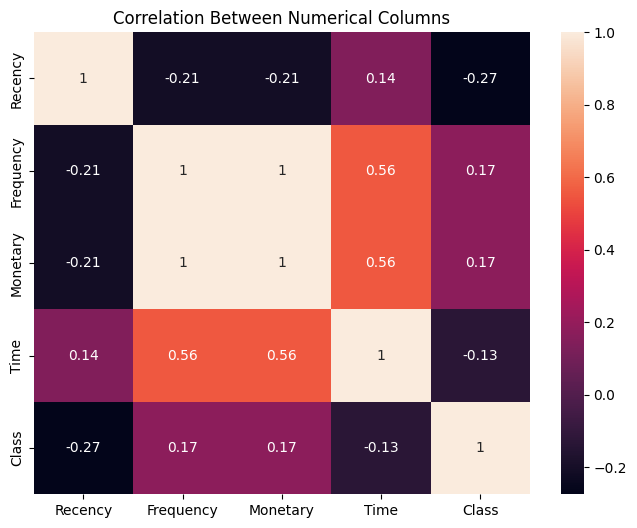

Dataset: boston.csv

rows and columns: (506, 14)

Column names:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']

Missing values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

Duplicate rows: 0

Basic statistics:
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      

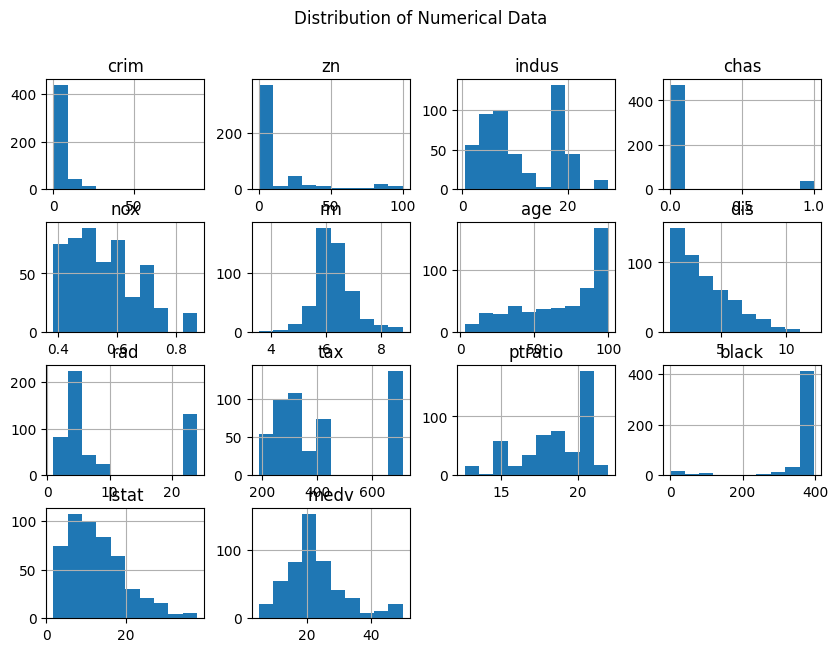

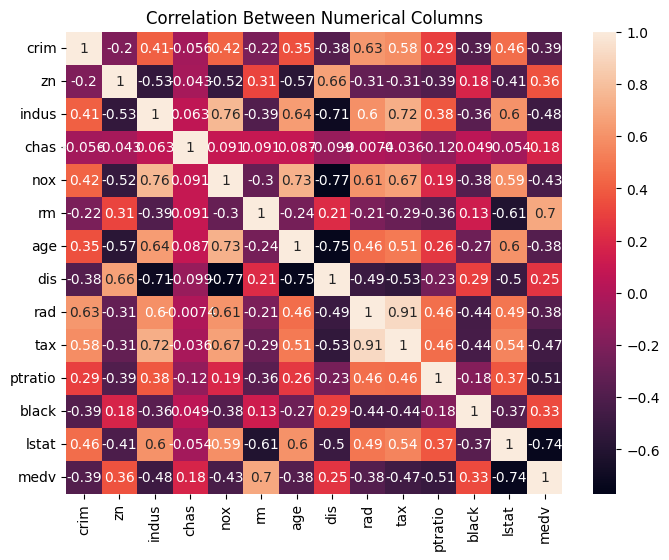

Dataset: cancer.csv

rows and columns: (683, 10)

Column names:
['Class', 'age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad', 'irradiat']

Missing values:
Class          0
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
dtype: int64

Duplicate rows: 234

Basic statistics:
            Class         age   menopause  tumor-size   inv-nodes   node-caps  \
count  683.000000  683.000000  683.000000  683.000000  683.000000  683.000000   
mean     0.349927    4.442167    3.150805    3.215227    2.830161    3.234261   
std      0.477296    2.820761    3.065145    2.988581    2.864562    2.223085   
min      0.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      0.000000    2.000000    1.000000    1.000000    1.000000    2.000000   
50%      0.000000    4.000000    1.000000    1.000000    1.000000    2.000000   
75%      

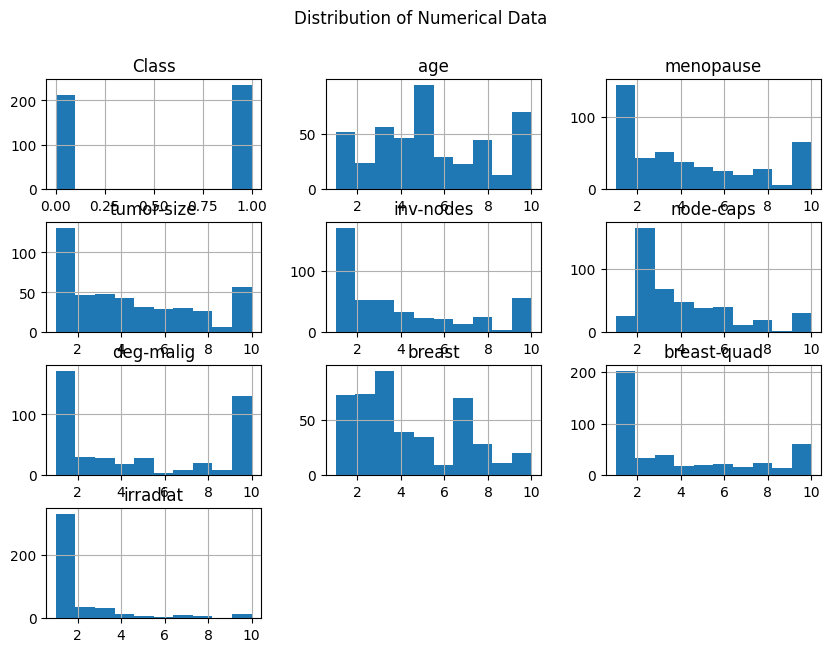

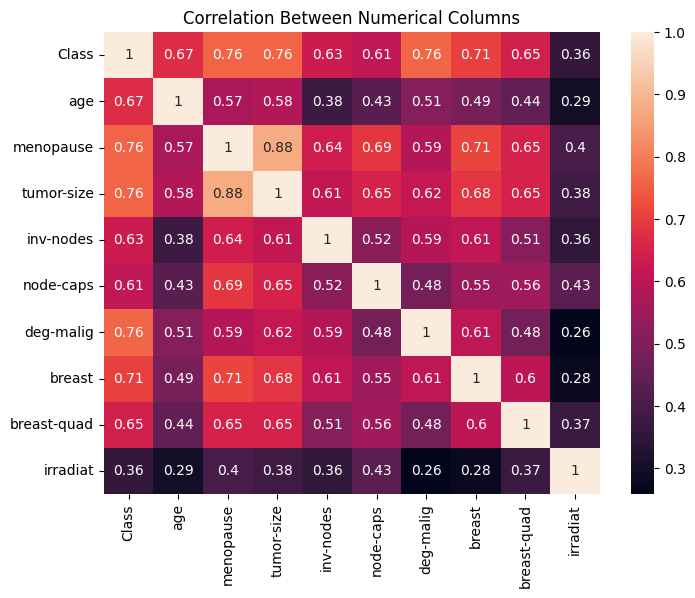

Dataset: concrete.csv

rows and columns: (1030, 9)

Column names:
['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'strength']

Missing values:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
strength                                                 0
dty

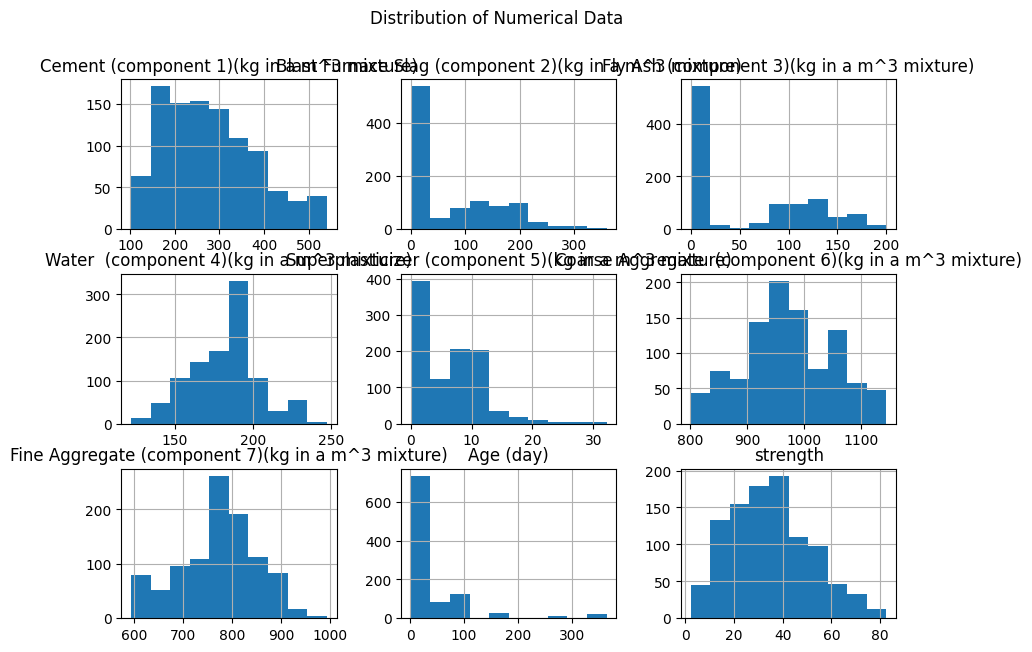

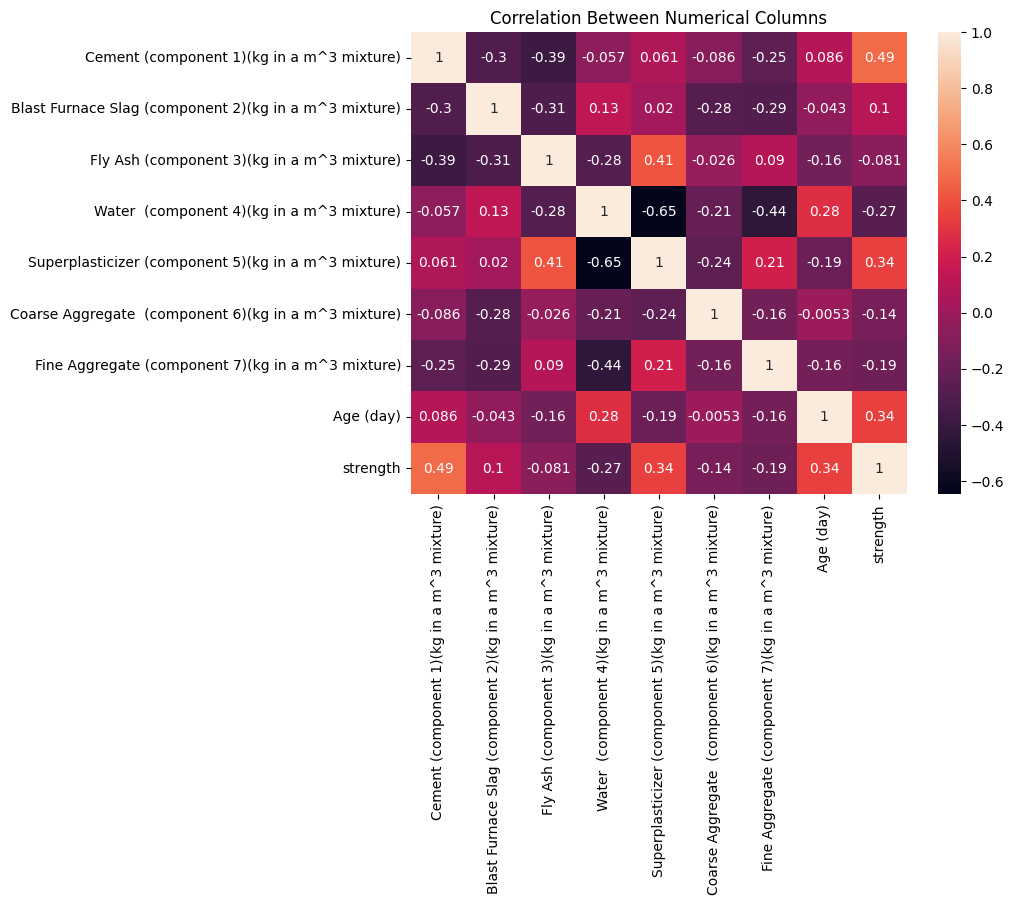

Dataset: diabetes.csv

rows and columns: (768, 9)

Column names:
['Number of times pregnant', 'Plasma glucose concentration a 2 hours in an oral glucose tolerance test', 'Diastolic blood pressure (mm Hg)', 'Triceps skin fold thickness (mm)', '2-Hour serum insulin (mu U/ml)', 'Body mass index (weight in kg/(height in m)^2)', 'Diabetes pedigree function', 'Age (years)', 'Class variable']

Missing values:
Number of times pregnant                                                    0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
Diastolic blood pressure (mm Hg)                                            0
Triceps skin fold thickness (mm)                                            0
2-Hour serum insulin (mu U/ml)                                              0
Body mass index (weight in kg/(height in m)^2)                              0
Diabetes pedigree function                                                  0
Age (years)                                     

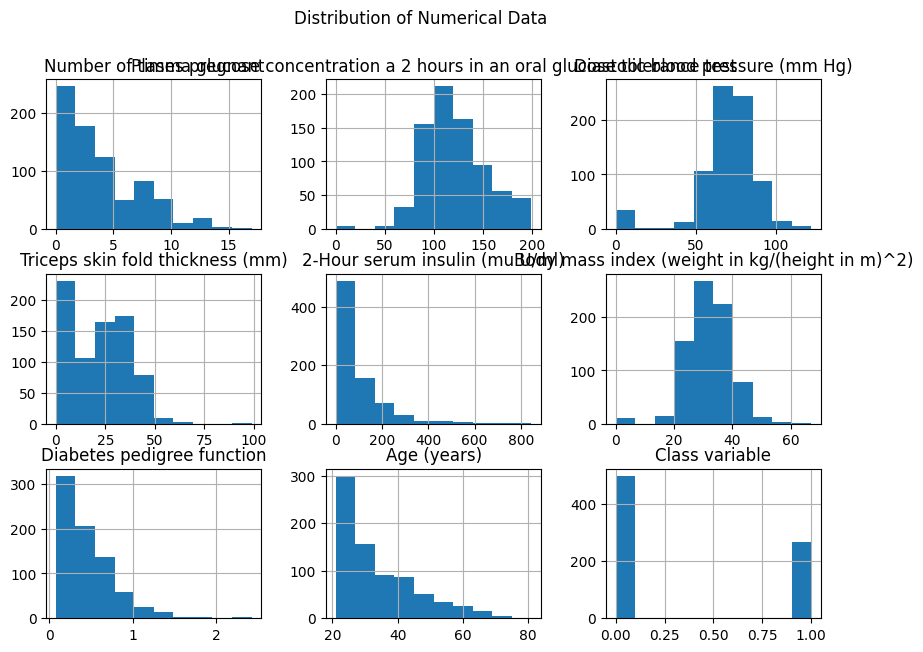

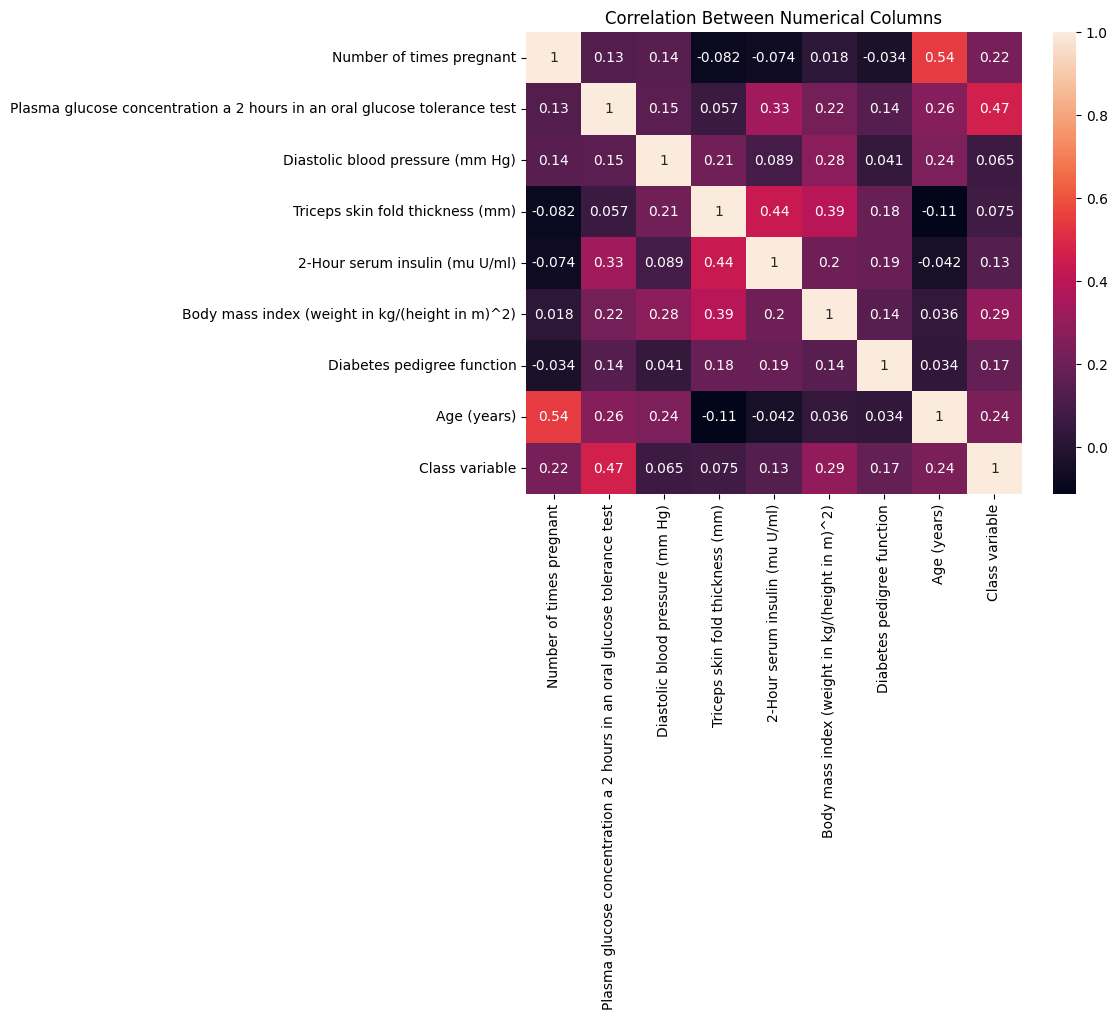

Dataset: energy.csv

rows and columns: (768, 10)

Column names:
['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area', 'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution', 'Heating Load', 'Cooling Load']

Missing values:
Relative Compactness         0
Surface Area                 0
Wall Area                    0
Roof Area                    0
Overall Height               0
Orientation                  0
Glazing Area                 0
Glazing Area Distribution    0
Heating Load                 0
Cooling Load                 0
dtype: int64

Duplicate rows: 0

Basic statistics:
       Relative Compactness  Surface Area   Wall Area   Roof Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.3

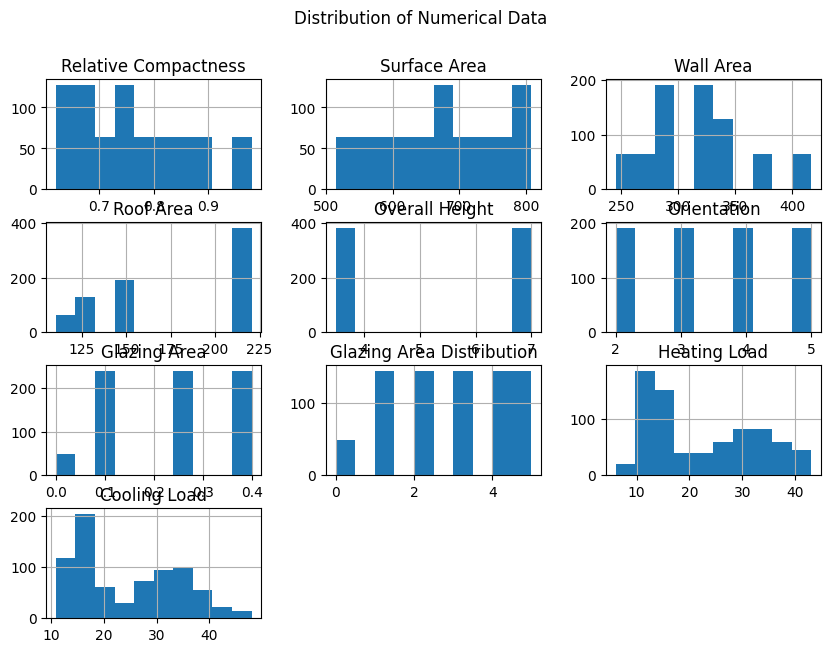

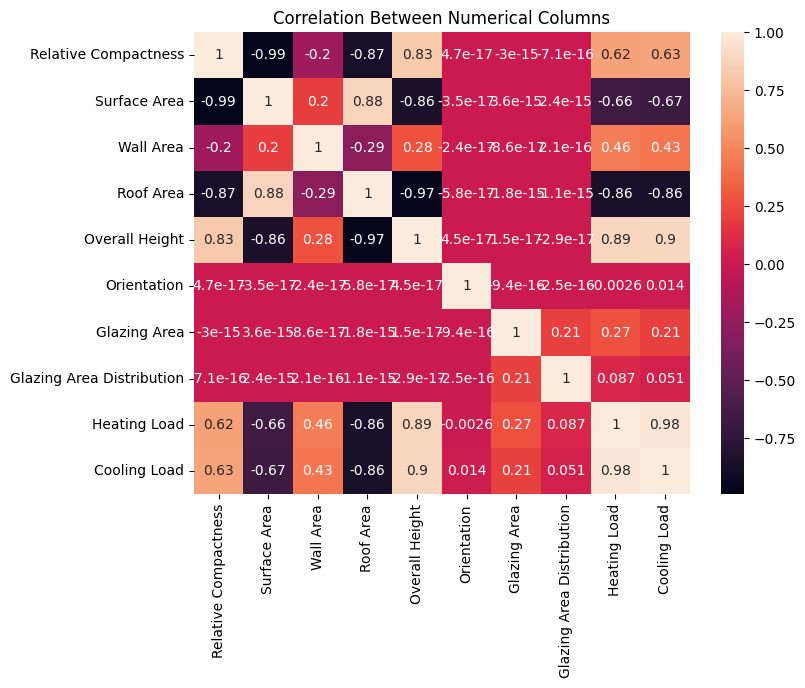

Dataset: forest.csv

rows and columns: (517, 13)

Column names:
['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']

Missing values:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Duplicate rows: 4

Basic statistics:
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000

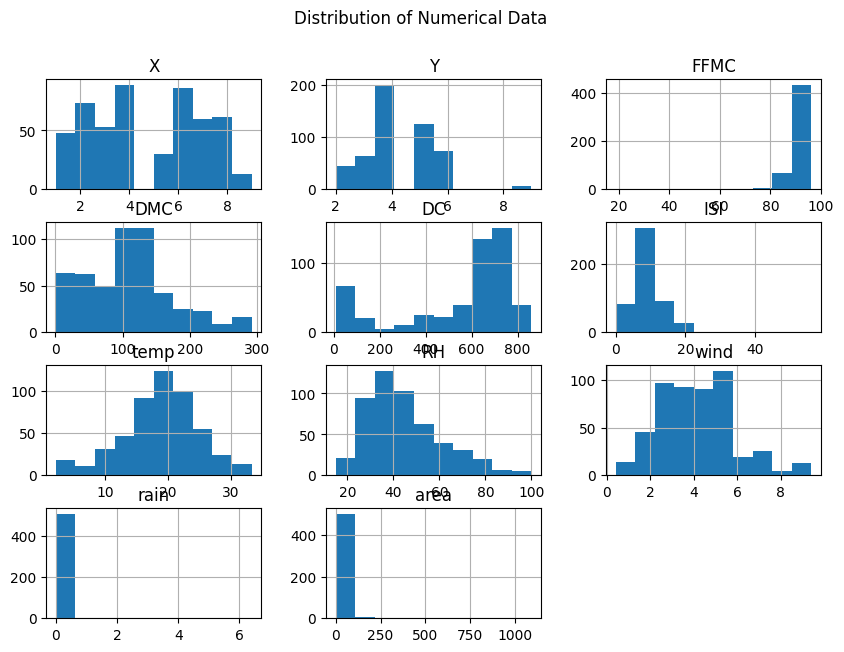

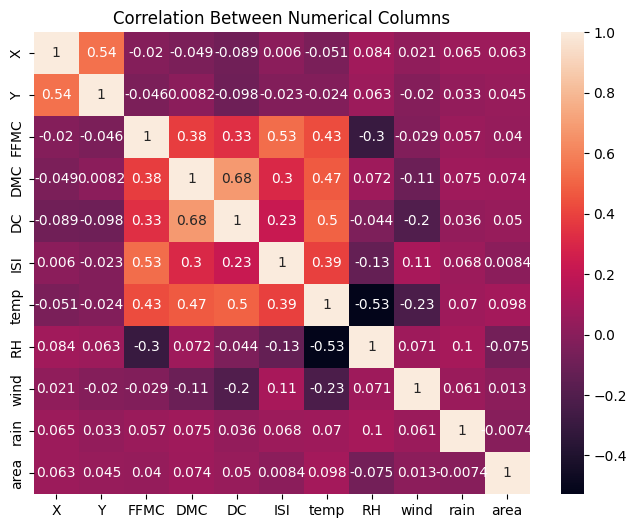

Dataset: diamond.csv

rows and columns: (6000, 8)

Column names:
['Carat Weight', 'Cut', 'Color', 'Clarity', 'Polish', 'Symmetry', 'Report', 'Price']

Missing values:
Carat Weight    0
Cut             0
Color           0
Clarity         0
Polish          0
Symmetry        0
Report          0
Price           0
dtype: int64

Duplicate rows: 83

Basic statistics:
       Carat Weight          Price
count   6000.000000    6000.000000
mean       1.334520   11791.579333
std        0.475696   10184.350051
min        0.750000    2184.000000
25%        1.000000    5150.500000
50%        1.130000    7857.000000
75%        1.590000   15036.500000
max        2.910000  101561.000000

Cleaning completed!


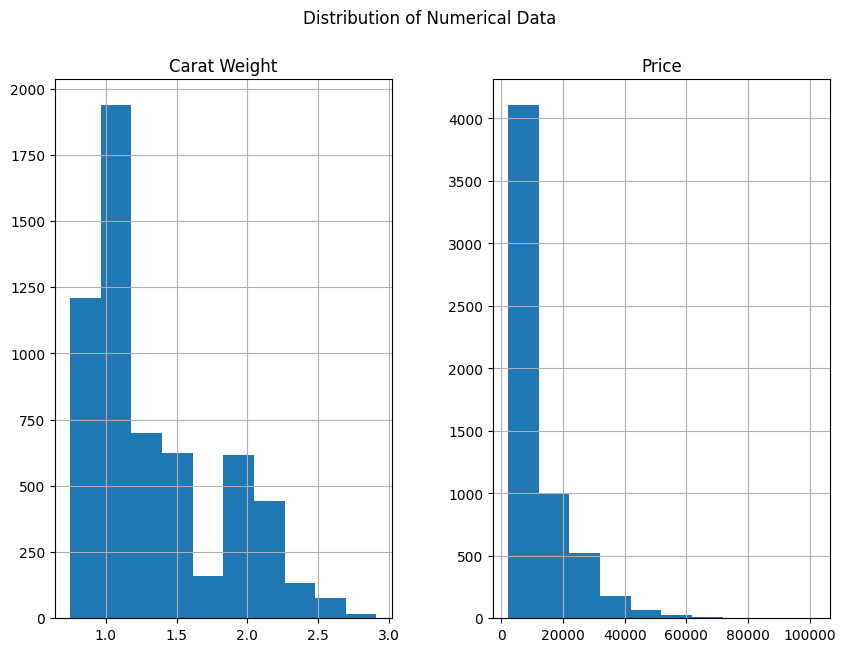

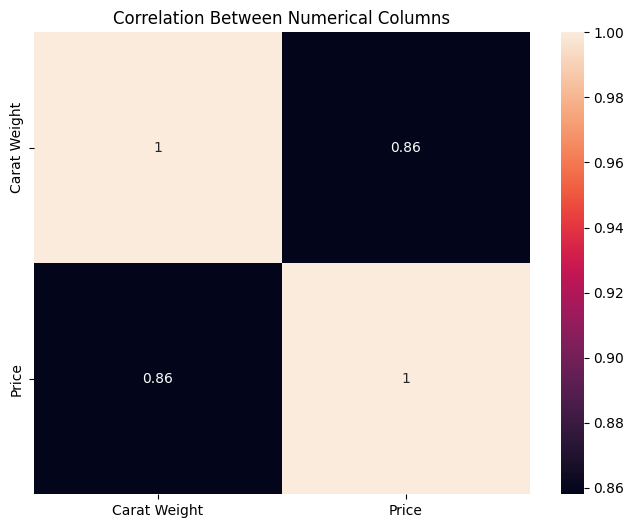

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_names = [
    "asia_gdp.csv",
    "automobile.csv",
    "blood.csv",
    "boston.csv",
    "cancer.csv",
    "concrete.csv",
    "diabetes.csv",
    "energy.csv",
    "forest.csv",
    "diamond.csv"
]

for file_name in dataset_names:


    print("Dataset:", file_name)
    data = pd.read_csv(file_name)
    print("\nrows and columns:", data.shape)
    print("\nColumn names:")
    print(data.columns.tolist())
    print("\nMissing values:")
    print(data.isnull().sum())
    print("\nDuplicate rows:", data.duplicated().sum())
    print("\nBasic statistics:")
    print(data.describe())
    data = data.drop_duplicates()
    number_columns = data.select_dtypes(include="number").columns
    for column in number_columns:
        data[column] = data[column].fillna(data[column].median())
    print("\nCleaning completed!")
    data[number_columns].hist(figsize=(10, 7))
    plt.suptitle("Distribution of Numerical Data")
    plt.show()
    if len(number_columns) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(data[number_columns].corr(), annot=True)
        plt.title("Correlation Between Numerical Columns")
        plt.show()
